In [171]:
import os

import numpy as np
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = kagglehub.competition_download('alzheimers-disease-risk-prediction-eu-business')
print("Path to competition files:", path)

100%|████████████████████████████████████████████████████████████████████████████████| 272k/272k [00:00<00:00, 525kB/s]

Extracting files...
Path to competition files: /home/alexandre/.cache/kagglehub/competitions/alzheimers-disease-risk-prediction-eu-business


In [5]:
print("Competition data Directory files: ")
for file in os.listdir(path):
    print(file, "; path=", os.path.join(path,file))

Competition data Directory files: 
train.csv ; path= /home/alexandre/.cache/kagglehub/competitions/alzheimers-disease-risk-prediction-eu-business/train.csv
submission_template.csv ; path= /home/alexandre/.cache/kagglehub/competitions/alzheimers-disease-risk-prediction-eu-business/submission_template.csv
test.csv ; path= /home/alexandre/.cache/kagglehub/competitions/alzheimers-disease-risk-prediction-eu-business/test.csv
data_description.txt ; path= /home/alexandre/.cache/kagglehub/competitions/alzheimers-disease-risk-prediction-eu-business/data_description.txt


In [8]:
!cat "$path/data_description.txt"

About Dataset
This dataset contains extensive health information for 2,149 patients, each uniquely identified. The dataset includes demographic details, lifestyle factors, medical history, clinical measurements, cognitive and functional assessments, symptoms, and a diagnosis of Alzheimer's Disease. The data is ideal for researchers and data scientists looking to explore factors associated with Alzheimer's, develop predictive models, and conduct statistical analyses.

Table of Contents
Demographic Details
Lifestyle Factors
Medical History
Clinical Measurements
Cognitive and Functional Assessments
Symptoms
Diagnosis Information

Demographic Details
Age: The age of the patients ranges from 60 to 90 years.
Gender: Gender of the patients, where 0 represents Male and 1 represents Female.
Ethnicity: The ethnicity of the patients, coded as follows:
0: Caucasian
1: African American
2: Asian
3: Other

Lifestyle Factors
BMI: Body Mass Index of the patients, ranging from 15 to 40.
Smoking: Smoking

---

## Getting in touch with the data

In [11]:
train_df = pd.read_csv(os.path.join(path,"train.csv"))
test_df = pd.read_csv(os.path.join(path,"test.csv"))

In [12]:
train_df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,6184,87,1,2,1,27.764232,1,16.543170,0.281379,5.923418,...,0,0,6.643693,0,0,0,0,0,0,XXXConfid
1,5381,70,0,0,3,37.098744,0,1.360202,9.242990,1.819284,...,0,1,3.884562,0,0,0,0,1,1,XXXConfid
2,4829,82,1,3,2,15.908275,0,16.329031,1.915913,6.607292,...,0,0,4.013722,0,0,1,1,0,1,XXXConfid
3,5117,76,1,0,2,30.302432,1,11.814030,6.281170,6.204349,...,0,0,9.355700,1,0,1,0,1,0,XXXConfid
4,6747,61,0,0,2,24.565357,1,2.273373,9.976581,2.057188,...,1,0,8.818932,0,1,0,0,0,1,XXXConfid


In [19]:
print("DF for training, columns: ")
print(train_df.columns)
print("total columns: ", len(train_df.columns))

DF for training, columns: 
Index(['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI',
       'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality',
       'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease',
       'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP',
       'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Diagnosis', 'DoctorInCharge'],
      dtype='str')
total columns:  35


In [20]:
print("DF for testing, columns: ")
print(test_df.columns)
print("total columns: ", len(test_df.columns))

DF for testing, columns: 
Index(['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI',
       'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality',
       'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease',
       'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP',
       'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'DoctorInCharge'],
      dtype='str')
total columns:  34


At first glance, columns like: `PatientID` and `DoctorInCharge`; are the first ones to be removed. They will not give us any sort of useful information during our analysis.

Now, we need to know the data format and if there're any missing data

In [27]:
print("DF info - training: ")
display(train_df.info())

print("="* 60)

print("DF info - testing: ")
display(test_df.info())

DF info - training: 
<class 'pandas.DataFrame'>
RangeIndex: 1719 entries, 0 to 1718
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  1719 non-null   int64  
 1   Age                        1719 non-null   int64  
 2   Gender                     1719 non-null   int64  
 3   Ethnicity                  1719 non-null   int64  
 4   EducationLevel             1719 non-null   int64  
 5   BMI                        1719 non-null   float64
 6   Smoking                    1719 non-null   int64  
 7   AlcoholConsumption         1719 non-null   float64
 8   PhysicalActivity           1719 non-null   float64
 9   DietQuality                1719 non-null   float64
 10  SleepQuality               1719 non-null   float64
 11  FamilyHistoryAlzheimers    1719 non-null   int64  
 12  CardiovascularDisease      1719 non-null   int64  
 13  Diabetes                   1719 non-nu

None

DF info - testing: 
<class 'pandas.DataFrame'>
RangeIndex: 430 entries, 0 to 429
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  430 non-null    int64  
 1   Age                        430 non-null    int64  
 2   Gender                     430 non-null    int64  
 3   Ethnicity                  430 non-null    int64  
 4   EducationLevel             430 non-null    int64  
 5   BMI                        430 non-null    float64
 6   Smoking                    430 non-null    int64  
 7   AlcoholConsumption         430 non-null    float64
 8   PhysicalActivity           430 non-null    float64
 9   DietQuality                430 non-null    float64
 10  SleepQuality               430 non-null    float64
 11  FamilyHistoryAlzheimers    430 non-null    int64  
 12  CardiovascularDisease      430 non-null    int64  
 13  Diabetes                   430 non-null  

None

In [30]:
print("DF NULLS and NAN - training: ")
print("NULLS:")
display(train_df.isnull().sum())
print("NAN:")
display(train_df.isna().sum())

print("="* 60)

print("DF NULLS and NAN - testing: ")
print("NULLS:")
display(test_df.isnull().sum())
print("NAN:")
display(test_df.isna().sum())


DF NULLS and NAN - training: 
NULLS:


PatientID                    0
Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
DifficultyCompletingTasks    0
Forgetfu

NAN:


PatientID                    0
Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
DifficultyCompletingTasks    0
Forgetfu

DF NULLS and NAN - testing: 
NULLS:


PatientID                    0
Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
DifficultyCompletingTasks    0
Forgetfu

NAN:


PatientID                    0
Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
DifficultyCompletingTasks    0
Forgetfu

There's no missing data, which is expected since it was provided by a kaggle competition 

Let's see how proportional the data is

In [34]:
total_tr = len(train_df)
total_ts = len(test_df)
total_all = total_tr + total_ts
tr_ratio = total_tr / total_all
ts_ratio = total_ts / total_all

print("total training: ", total_tr, "; ratio=",tr_ratio*100)
print("total testing: ", total_ts, "; ratio=",ts_ratio*100) 
print("total all: ", total_all)

total training:  1719 ; ratio= 79.9906933457422
total testing:  430 ; ratio= 20.009306654257795
total all:  2149


They used something like $80\%$ for training and $20\%$ for testing, which is reasonable given the amount of data

In [56]:
train_df.describe()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,1719.000000,1719.000000,1719.000000,1719.000000,1719.000000,1719.000000,1719.000000,1719.000000,1719.000000,1719.000000,...,1719.000000,1719.000000,1719.000000,1719.000000,1719.000000,1719.000000,1719.000000,1719.000000,1719.000000,1719.000000
mean,5822.347877,74.960442,0.500291,0.698080,1.283304,27.687408,0.286795,9.978133,4.942195,4.972312,...,5.069688,0.205934,0.156486,4.970744,0.201280,0.158813,0.148342,0.161722,0.296684,0.353112
std,620.850386,9.065000,0.500145,0.994836,0.904339,7.209284,0.452396,5.777363,2.827319,2.900920,...,2.890435,0.404500,0.363422,2.947606,0.401073,0.365608,0.355542,0.368303,0.456929,0.478076
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,...,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5292.500000,67.000000,0.000000,0.000000,1.000000,21.641242,0.000000,5.137582,2.612521,2.415726,...,2.562307,0.000000,0.000000,2.324166,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5820.000000,75.000000,1.000000,0.000000,1.000000,27.919813,0.000000,9.805564,4.801357,5.050778,...,5.098709,0.000000,0.000000,5.026306,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6357.500000,83.000000,1.000000,1.000000,2.000000,33.842594,1.000000,15.181033,7.380416,7.480424,...,7.496824,0.000000,0.000000,7.583825,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.997203,...,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [57]:
test_df.describe()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness
count,430.000000,430.000000,430.000000,430.000000,430.000000,430.000000,430.000000,430.000000,430.000000,430.000000,...,430.000000,430.000000,430.000000,430.000000,430.000000,430.000000,430.000000,430.000000,430.000000,430.000000
mean,5835.602326,74.702326,0.530233,0.695349,1.300000,27.528926,0.295349,10.284535,4.832282,5.076394,...,14.823642,5.121497,0.216279,0.158140,5.031786,0.220930,0.155814,0.160465,0.146512,0.320930
std,619.741632,8.692077,0.499667,1.002434,0.906208,7.256982,0.456731,5.679516,2.975384,2.943282,...,8.517329,2.904957,0.412186,0.365297,2.961366,0.415357,0.363101,0.367464,0.354030,0.467378
min,4764.000000,60.000000,0.000000,0.000000,0.000000,15.012071,0.000000,0.103460,0.019957,0.016446,...,0.018022,0.011898,0.000000,0.000000,0.009274,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5280.250000,68.000000,0.000000,0.000000,1.000000,21.599956,0.000000,5.374553,2.160949,2.600685,...,7.633091,2.571119,0.000000,0.000000,2.436423,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5839.000000,74.000000,1.000000,0.000000,1.000000,27.262867,0.000000,10.645820,4.546221,5.264088,...,14.653224,5.050955,0.000000,0.000000,5.137038,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6384.250000,82.000000,1.000000,1.000000,2.000000,34.040360,1.000000,15.099557,7.604445,7.782808,...,21.752716,7.689087,0.000000,0.000000,7.548981,0.000000,0.000000,0.000000,0.000000,1.000000
max,6898.000000,90.000000,1.000000,3.000000,3.000000,39.981533,1.000000,19.988291,9.984090,9.998346,...,29.950813,9.992610,1.000000,1.000000,9.972663,1.000000,1.000000,1.000000,1.000000,1.000000


In [35]:
TARGET = "Diagnosis"

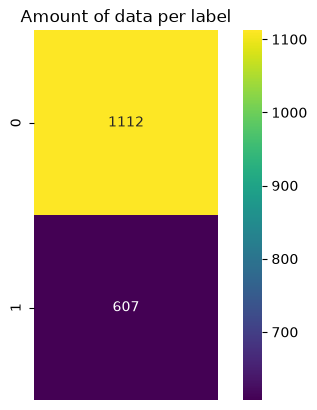

In [53]:
target_train = train_df[TARGET]
# test doesn't have the target column, so it's mainly used for evaluating and submitting to the challenge on Kaggle

matrix_amounts = target_train.value_counts().reset_index()["count"].to_numpy().reshape((-1,1))
ax = sns.heatmap(matrix_amounts, cmap="viridis", annot=True, square=True, fmt=".0f",)
ax.set_title("Amount of data per label")
ax.set_xticks([])
plt.show()

I don't know exactly if this propotion is good or bad, we need to explore it a bit more

---

## Exploring data by demographics details


Age: The age of the patients ranges from 60 to 90 years.

Gender: Gender of the patients, where 0 represents Male and 1 represents Female.

Ethnicity: The ethnicity of the patients, coded as follows:\
0: Caucasian\
1: African American\
2: Asian\
3: Other

In [78]:
demo_cols = ["Age", "Gender", "Ethnicity", "Diagnosis"]
demo_df = train_df[demo_cols]

demo_df['Gender'] = demo_df['Gender'].map({0:"Male", 1:"Female"})
demo_df['Ethnicity'] = demo_df['Ethnicity'].map({0:"Caucasian", 1:"African American", 2:"Asian", 3:"Other"})
demo_df.head()

,Age,Gender,Ethnicity,Diagnosis
0,87,Female,Asian,0
1,70,Male,Caucasian,1
2,82,Female,Other,1
3,76,Female,Caucasian,0
4,61,Male,Caucasian,1


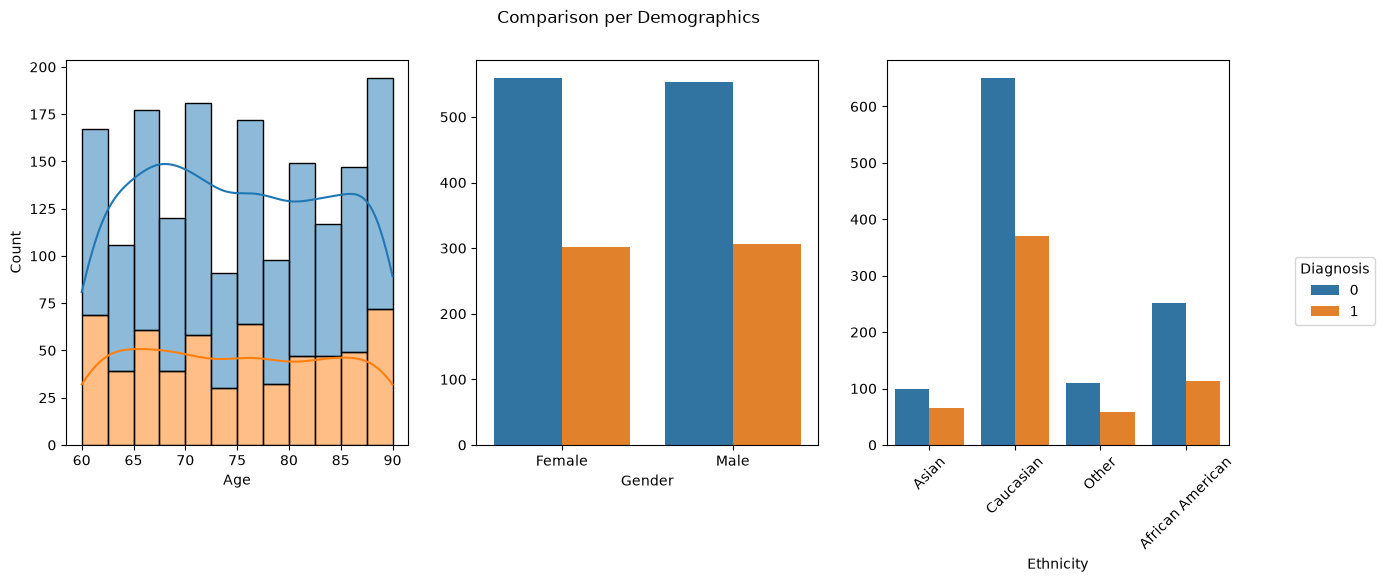

In [89]:
fig,ax = plt.subplots(1,3, figsize=(15,5))

sns.histplot(data=demo_df, x="Age", hue="Diagnosis", multiple="stack", kde=True, ax=ax[0])
sns.countplot(data=demo_df, x="Gender", hue="Diagnosis",ax=ax[1],legend=False)
sns.countplot(data=demo_df, x="Ethnicity", hue="Diagnosis",ax=ax[2],legend=True)

for i in range(1,3): 
    ax[i].set_ylabel("")
    
for i in range(3):
    legend = ax[i].get_legend()
    if legend:
        legend.remove()
ax[-1].tick_params(axis='x', rotation=45)

fig.suptitle("Comparison per Demographics")
fig.legend(loc="center right", title="Diagnosis")
plt.show()

Age an gender seems balanced. However, the sample given to us has too many Caucasian people, which can diverge in some way our analysis. Maybe if this information is not relavant, we could simply drop off. But let's dive in.

---

## Exploring lifestyle factors

BMI: Body Mass Index of the patients, ranging from 15 to 40.

Smoking: Smoking status, where 0 indicates No and 1 indicates Yes.

AlcoholConsumption: Weekly alcohol consumption in units, ranging from 0 to 20.

PhysicalActivity: Weekly physical activity in hours, ranging from 0 to 10.

DietQuality: Diet quality score, ranging from 0 to 10.

SleepQuality: Sleep quality score, ranging from 4 to 10.

In [90]:
life_cols = ["BMI", "Smoking", "AlcoholConsumption", "PhysicalActivity", "DietQuality", "SleepQuality", "Diagnosis"]
life_df = train_df[life_cols]
life_df.head()

,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,Diagnosis
0,27.764232,1,16.543170,0.281379,5.923418,7.836104,0
1,37.098744,0,1.360202,9.242990,1.819284,5.218052,1
2,15.908275,0,16.329031,1.915913,6.607292,6.146166,1
3,30.302432,1,11.814030,6.281170,6.204349,6.825155,0
4,24.565357,1,2.273373,9.976581,2.057188,4.715534,1


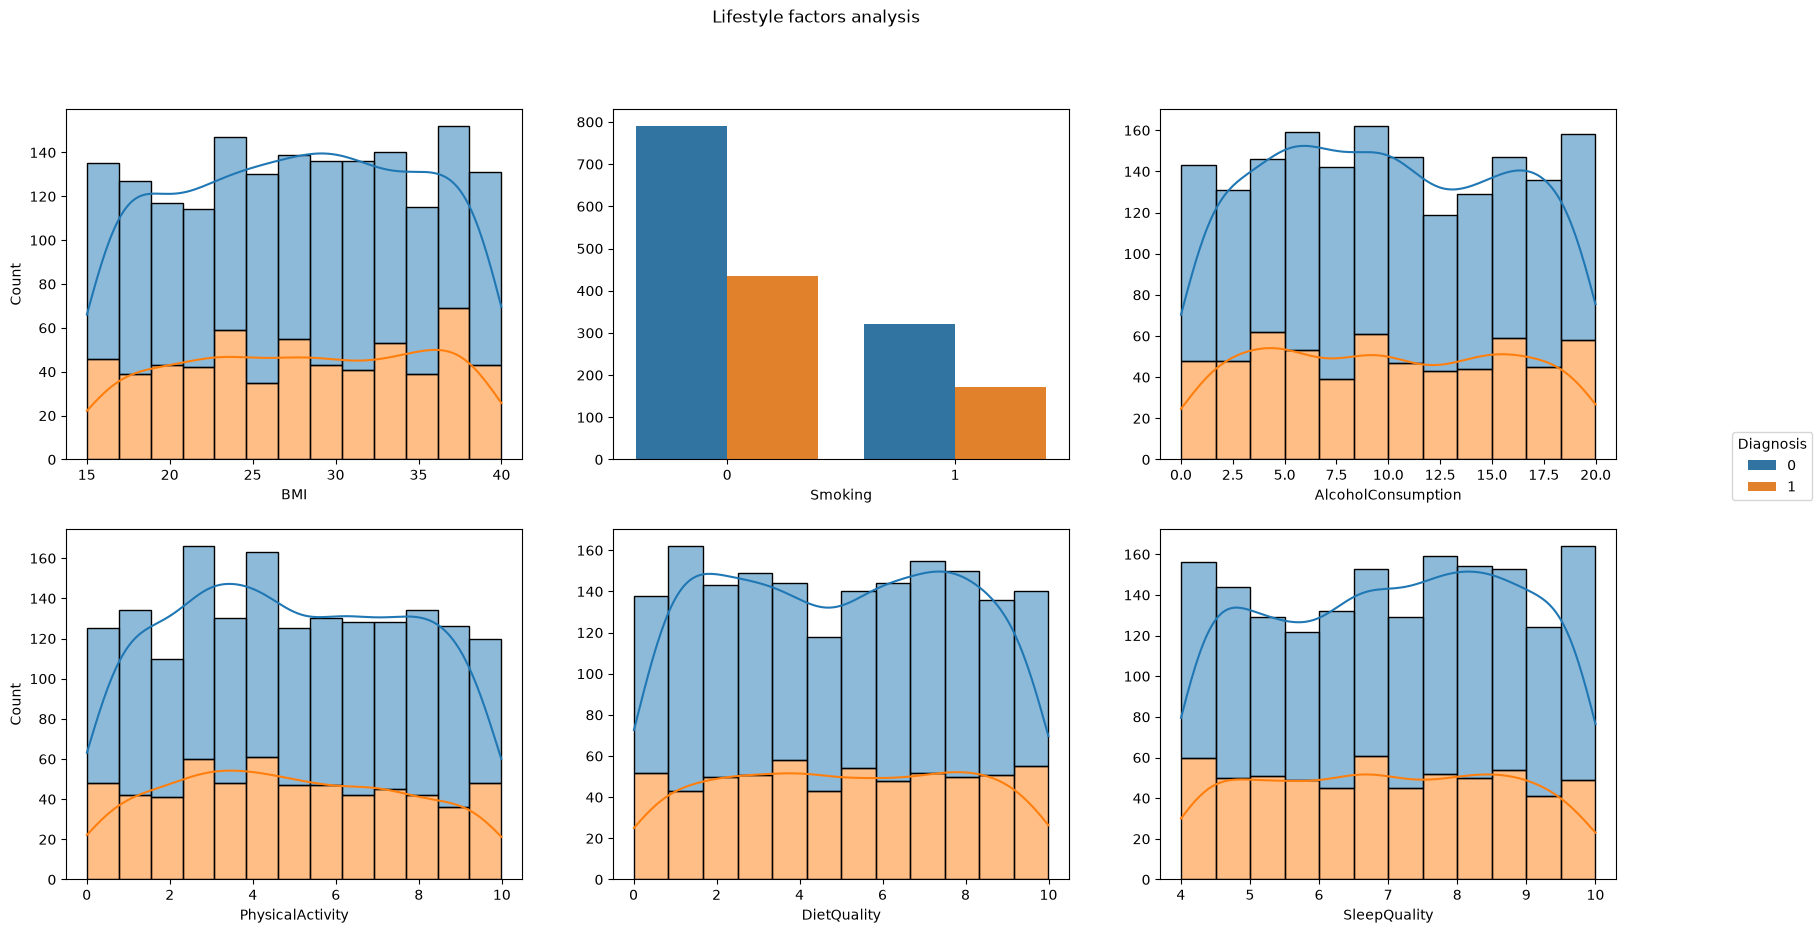

In [111]:
fig,ax = plt.subplots(2,3, figsize=(20,10))

sns.histplot(data=life_df, x="BMI", hue="Diagnosis", multiple="stack", kde=True, ax=ax[0,0], legend=False)
sns.countplot(data=life_df, x="Smoking", hue="Diagnosis", ax=ax[0,1], legend=True)
sns.histplot(data=life_df, x="AlcoholConsumption", hue="Diagnosis", multiple="stack", kde=True, ax=ax[0,2], legend=False)
sns.histplot(data=life_df, x="PhysicalActivity", hue="Diagnosis", multiple="stack", kde=True, ax=ax[1,0], legend=False)
sns.histplot(data=life_df, x="DietQuality", hue="Diagnosis", multiple="stack", kde=True, ax=ax[1,1], legend=False)
sns.histplot(data=life_df, x="SleepQuality", hue="Diagnosis", multiple="stack", kde=True, ax=ax[1,2], legend=False)

for i in range(2):
    for j in range(3):
        if [i,j] not in [[0,0], [1,0]]:
            ax[i,j].set_ylabel("")
        legend = ax[i,j].get_legend()
        if legend:
            legend.remove()
            
fig.suptitle("Lifestyle factors analysis")            
fig.legend(loc="center right", title="Diagnosis")
plt.show()


Maybe we should use a more/less health index/score.

Let's test BMI categorical using this table:

[![BMI index](./assets/BMI-index.png)](https://media.geeksforgeeks.org/wp-content/uploads/20231206171725/BMI-2.png)

In [125]:
bmi_df = life_df = train_df[["BMI", "Age", "Gender", "Ethnicity", "Diagnosis"]]

bmi_df['Gender'] = bmi_df['Gender'].map({0:"Male", 1:"Female"})
bmi_df['Ethnicity'] = bmi_df['Ethnicity'].map({0:"Caucasian", 1:"African American", 2:"Asian", 3:"Other"})

bmi_df["BMI_cat"] = "Underweight"
bmi_df.loc[(bmi_df["BMI"] >= 18.5)&(bmi_df["BMI"] < 25), "BMI_cat"] = "Normal"
bmi_df.loc[(bmi_df["BMI"] >= 25)&(bmi_df["BMI"] < 30), "BMI_cat"] = "Overweight"
bmi_df.loc[bmi_df["BMI"] >= 30, "BMI_cat"] = "Obese"
bmi_df.head()

,BMI,Age,Gender,Ethnicity,Diagnosis,BMI_cat
0,27.764232,87,Female,Asian,0,Overweight
1,37.098744,70,Male,Caucasian,1,Obese
2,15.908275,82,Female,Other,1,Underweight
3,30.302432,76,Female,Caucasian,0,Obese
4,24.565357,61,Male,Caucasian,1,Normal


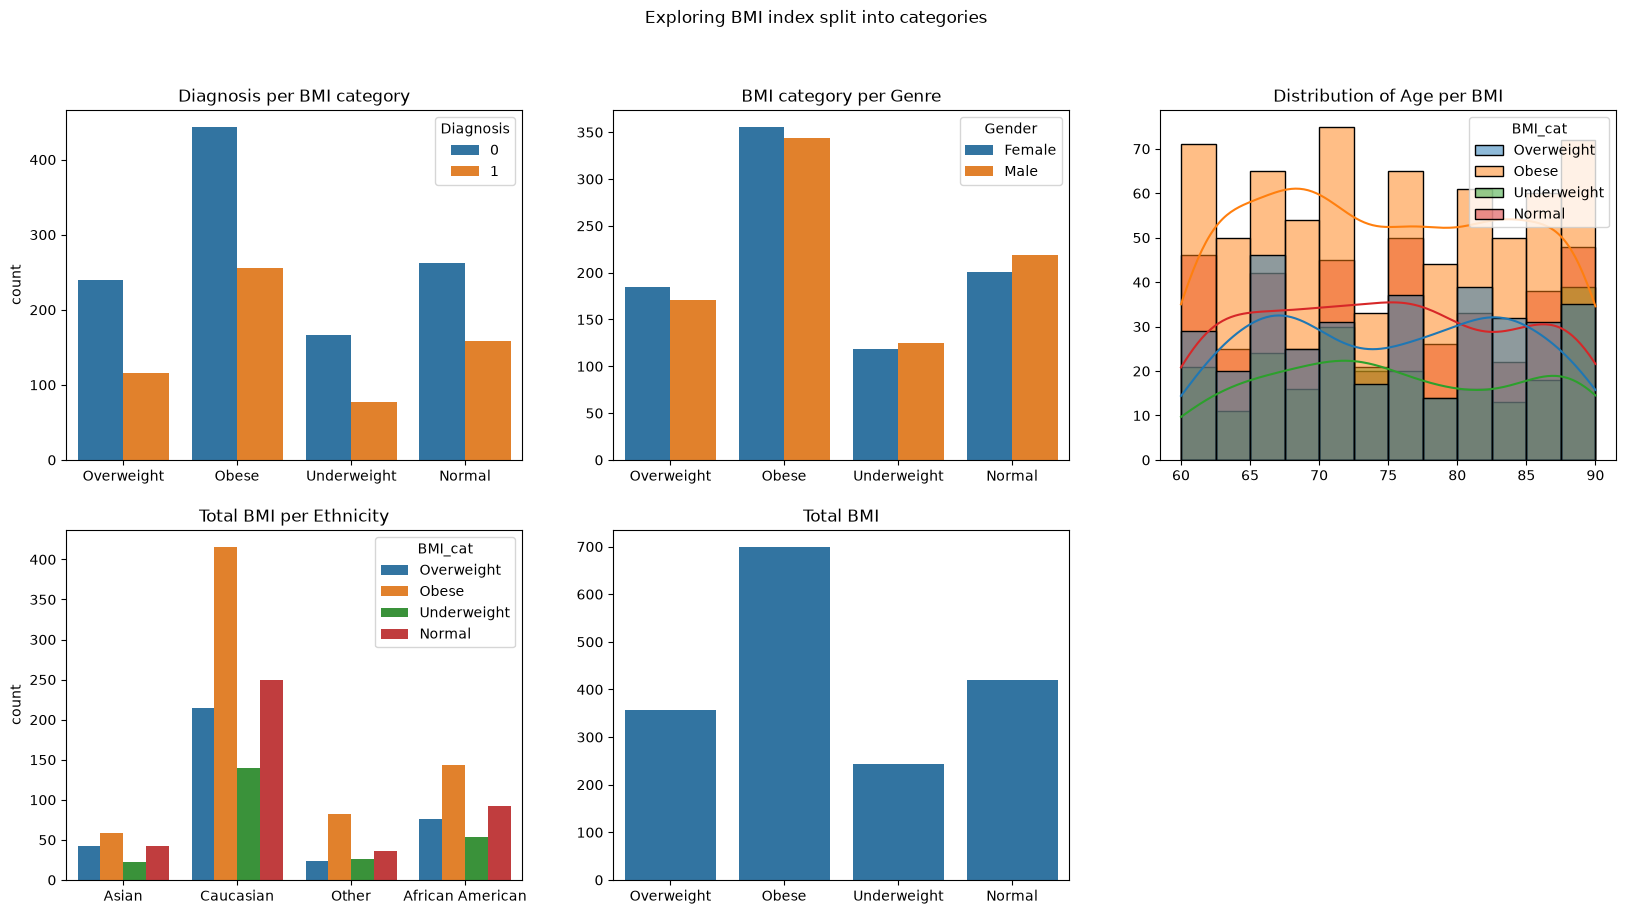

In [140]:
fig,ax = plt.subplots(2,3,figsize=(20,10))

sns.countplot(data=bmi_df, x="BMI_cat", hue="Diagnosis", ax=ax[0,0])
ax[0,0].set_title("Diagnosis per BMI category")

sns.countplot(data=bmi_df, x="BMI_cat", hue="Gender", ax=ax[0,1])
ax[0,1].set_title("BMI category per Genre")

sns.histplot(data=bmi_df, x="Age", hue="BMI_cat", kde=True, ax=ax[0,2])
ax[0,2].set_title("Distribution of Age per BMI")

sns.countplot(data=bmi_df, x="Ethnicity", hue="BMI_cat", ax=ax[1,0])
ax[1,0].set_title("Total BMI per Ethnicity")

sns.countplot(data=bmi_df, x="BMI_cat", ax=ax[1,1])
ax[1,1].set_title("Total BMI")


for i in range(2):
    for j in range(3):
        if [i,j] not in [[0,0],[1,0]]:
            ax[i,j].set_ylabel("")
        ax[i,j].set_xlabel("")

ax[0,0]
ax[-1,-1].remove()

fig.suptitle("Exploring BMI index split into categories")
plt.show()

### What we know till now?

- There'are way more Caucasians than other Ethnicities
- Most part of the people are obese
- Genders are balanced

---

## Exploring Medical History

FamilyHistoryAlzheimers: Family history of Alzheimer's Disease, where 0 indicates No and 1 indicates Yes.

CardiovascularDisease: Presence of cardiovascular disease, where 0 indicates No and 1 indicates Yes.

Diabetes: Presence of diabetes, where 0 indicates No and 1 indicates Yes.

Depression: Presence of depression, where 0 indicates No and 1 indicates Yes.

HeadInjury: History of head injury, where 0 indicates No and 1 indicates Yes.

Hypertension: Presence of hypertension, where 0 indicates No and 1 indicates Yes.

In [143]:
medical_cols = ["FamilyHistoryAlzheimers", "CardiovascularDisease", "Diabetes", "Depression", "HeadInjury", "Hypertension", "Diagnosis"]
medical_df = train_df[medical_cols]
medical_df.head()

,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,Diagnosis
0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,1
2,0,1,1,0,0,0,1
3,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1


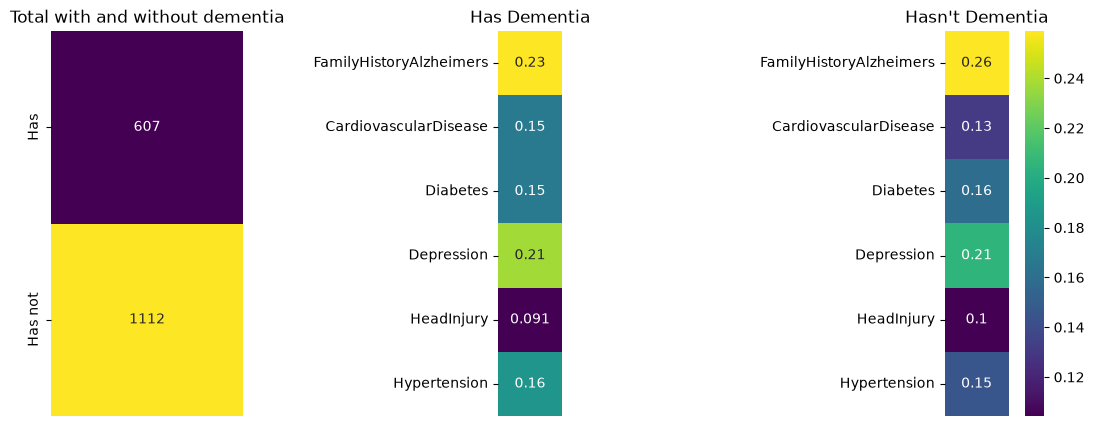

In [186]:
has_dementia = medical_df[medical_df.Diagnosis == 1]
has_not_dementia = medical_df[medical_df.Diagnosis == 0]

total_dementia = len(has_dementia)
total_no_dementia = len(has_not_dementia)

labels = medical_cols[:-1]

total_has_dementia = has_dementia[labels].sum().reset_index().rename(columns={0:"total"}).total.to_numpy().reshape((-1,1)) * (1/total_dementia)
total_has_not_dementia = has_not_dementia[labels].sum().reset_index().rename(columns={0:"total"}).total.to_numpy().reshape((-1,1)) * (1/total_no_dementia)

fig,ax = plt.subplots(1,3, figsize=(14,5))

sns.heatmap(np.array([[total_dementia], [total_no_dementia]]), cmap="viridis", annot=True, square=True, fmt=".0f", yticklabels=["Has", "Has not"], cbar=False, ax=ax[0])
sns.heatmap(total_has_dementia, cmap="viridis", annot=True, square=True, yticklabels=labels, cbar=False, ax=ax[1])
sns.heatmap(total_has_not_dementia, cmap="viridis", annot=True, square=True, yticklabels=labels, ax=ax[2])

ax[0].set_title("Total with and without dementia")
ax[1].set_title("Has Dementia")
ax[2].set_title("Hasn't Dementia")

for i in range(3):
    ax[i].set_xticks([])
plt.show()

---

## Exploring medical measures

SystolicBP: Systolic blood pressure, ranging from 90 to 180 mmHg.

DiastolicBP: Diastolic blood pressure, ranging from 60 to 120 mmHg.

CholesterolTotal: Total cholesterol levels, ranging from 150 to 300 mg/dL.

CholesterolLDL: Low-density lipoprotein cholesterol levels, ranging from 50 to 200 mg/dL.

CholesterolHDL: High-density lipoprotein cholesterol levels, ranging from 20 to 100 mg/dL.

CholesterolTriglycerides: Triglycerides levels, ranging from 50 to 400 mg/dL.

In [189]:
meas_cols = ["SystolicBP", "DiastolicBP", "CholesterolTotal", "CholesterolLDL", "CholesterolHDL", "CholesterolTriglycerides", "Diagnosis"]
meas_df = train_df[meas_cols]
meas_df.head()

,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,Diagnosis
0,165,104,152.867282,81.773928,36.315501,156.315737,0
1,144,93,172.951803,181.531732,59.846219,284.212782,1
2,90,112,234.274917,76.270979,96.793492,174.718861,1
3,95,119,233.623114,101.048013,23.251477,230.796600,0
4,169,69,286.509759,58.658641,78.508468,225.360895,1


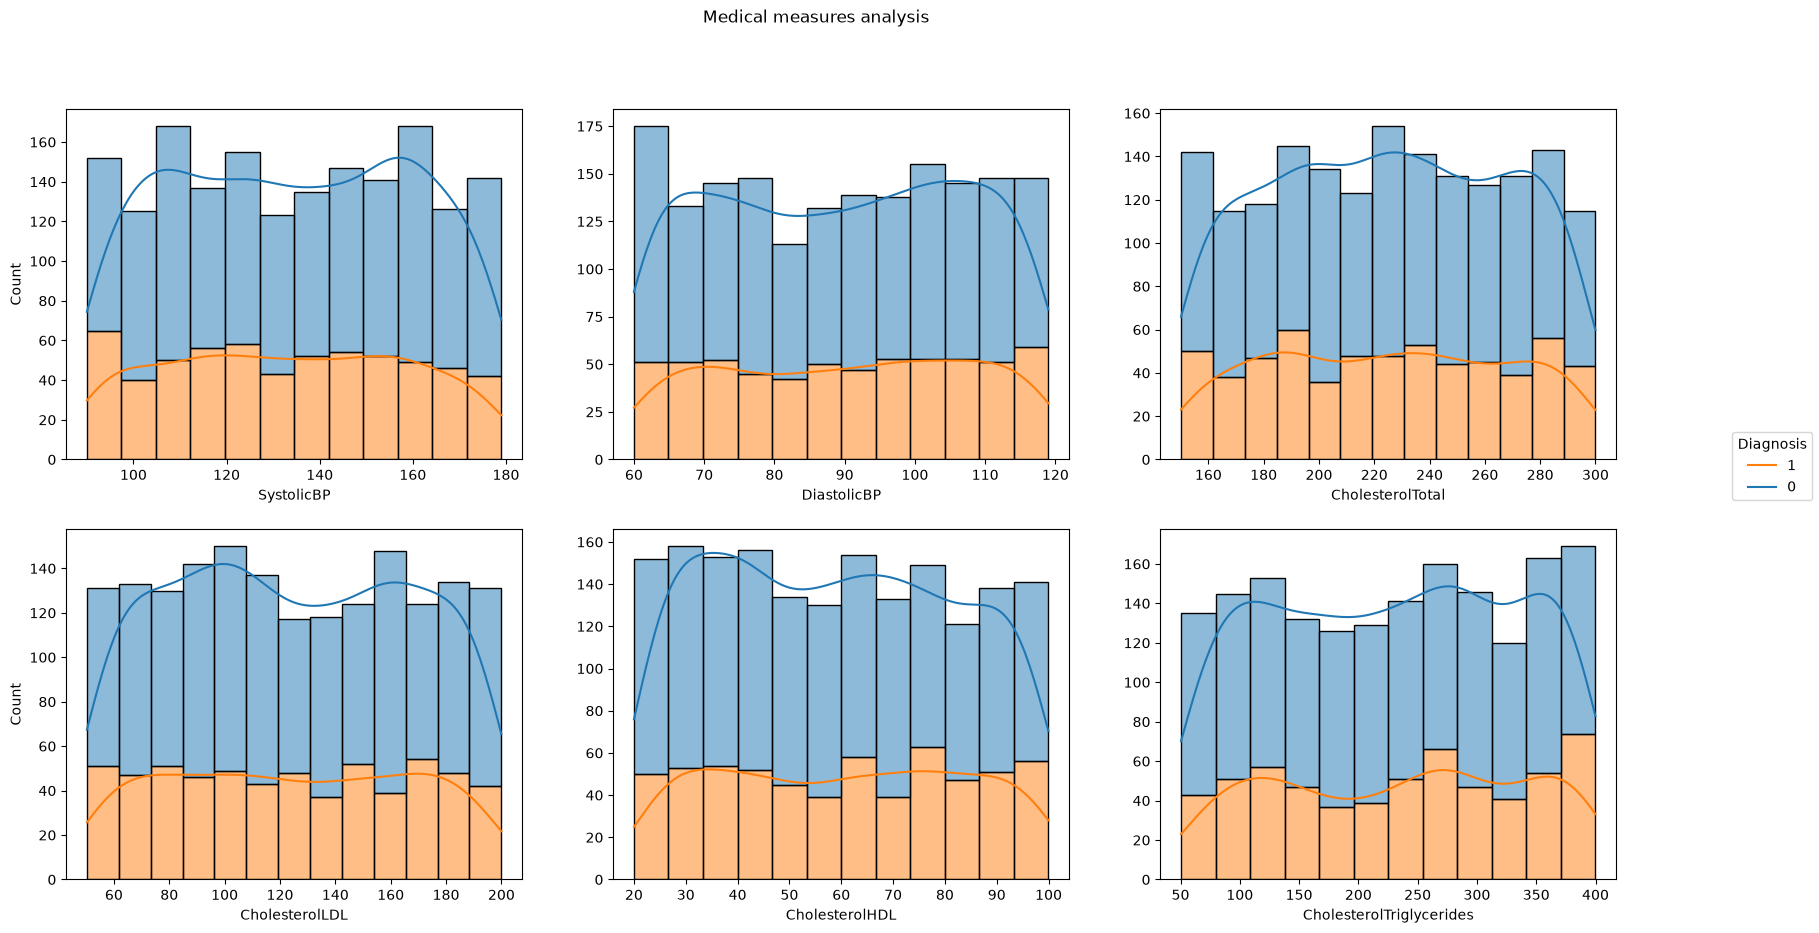

In [221]:
fig,ax = plt.subplots(2,3, figsize=(20,10))

sns.histplot(data=meas_df, x="SystolicBP", hue="Diagnosis", multiple="stack", kde=True, ax=ax[0,0],legend=True)
sns.histplot(data=meas_df, x="DiastolicBP", hue="Diagnosis", multiple="stack", kde=True, ax=ax[0,1], legend=False)
sns.histplot(data=meas_df, x="CholesterolTotal", hue="Diagnosis", multiple="stack", kde=True, ax=ax[0,2], legend=False)
sns.histplot(data=meas_df, x="CholesterolLDL", hue="Diagnosis", multiple="stack", kde=True, ax=ax[1,0], legend=False)
sns.histplot(data=meas_df, x="CholesterolHDL", hue="Diagnosis", multiple="stack", kde=True, ax=ax[1,1], legend=False)
sns.histplot(data=meas_df, x="CholesterolTriglycerides", hue="Diagnosis", multiple="stack", kde=True, ax=ax[1,2],legend=False)

for i in range(2):
    for j in range(3):
        if [i,j] not in [[0,0], [1,0]]:
            ax[i,j].set_ylabel("")
        legend = ax[i,j].get_legend()
        if legend:
            legend.remove()
            
fig.suptitle("Medical measures analysis")            
fig.legend([1,0], loc="center right", title="Diagnosis")
plt.show()

Even though nothing is shown here, it's strange, since the expected was to be higher probabilities for those with high Cholesterol for example. It may be the problem of imbalanced data.

---
### Exploring Cognitive tests

MMSE: Mini-Mental State Examination score, ranging from 0 to 30. Lower scores indicate cognitive impairment.

FunctionalAssessment: Functional assessment score, ranging from 0 to 10. Lower scores indicate greater impairment.

MemoryComplaints: Presence of memory complaints, where 0 indicates No and 1 indicates Yes.

BehavioralProblems: Presence of behavioral problems, where 0 indicates No and 1 indicates Yes.

ADL: Activities of Daily Living score, ranging from 0 to 10. Lower scores indicate greater impairment.

In [222]:
cogt_cols = ["MMSE", "FunctionalAssessment", "MemoryComplaints", "BehavioralProblems", "ADL", "Diagnosis"]
cogt_df = train_df[cogt_cols]
cogt_df.head()

,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Diagnosis
0,25.399206,3.085543,0,0,6.643693,0
1,8.292136,5.616830,0,1,3.884562,1
2,21.042238,3.662461,0,0,4.013722,1
3,28.609438,4.648135,0,0,9.355700,0
4,2.629135,9.601238,1,0,8.818932,1


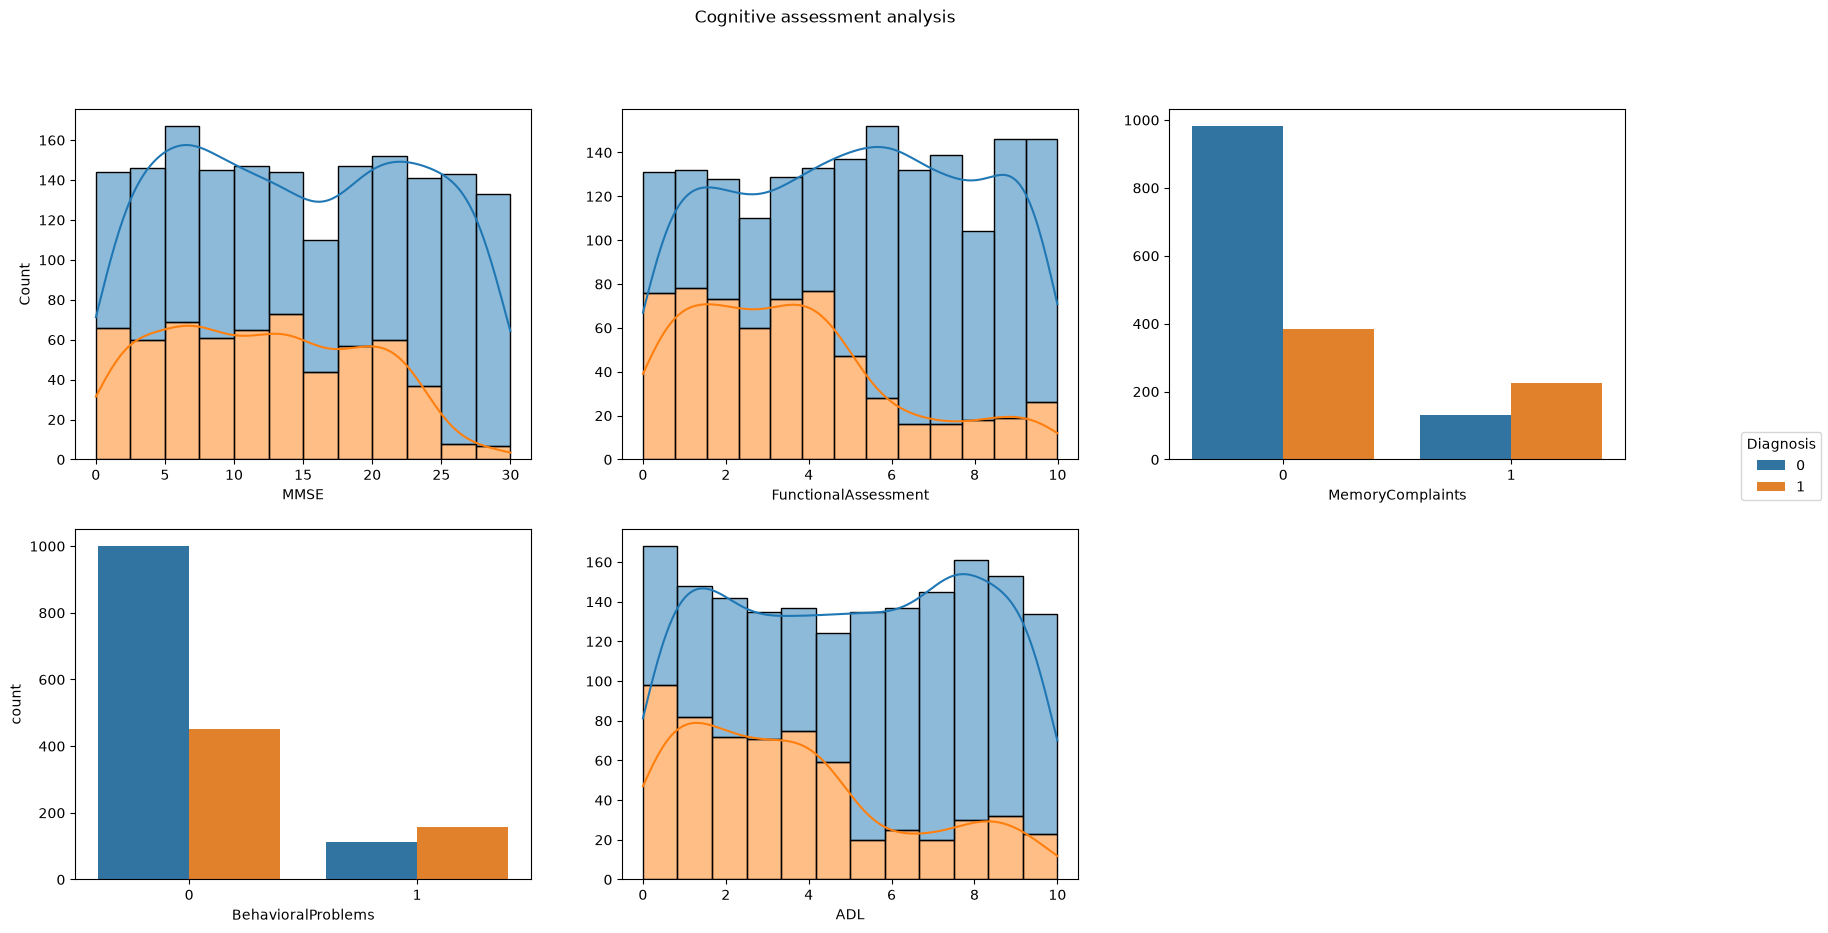

In [233]:
fig,ax = plt.subplots(2,3, figsize=(20,10))

sns.histplot(data=cogt_df, x="MMSE", hue="Diagnosis", multiple="stack", kde=True, ax=ax[0,0],legend=False)
sns.histplot(data=cogt_df, x="FunctionalAssessment", hue="Diagnosis", multiple="stack", kde=True, ax=ax[0,1],legend=False)
sns.countplot(data=cogt_df, x="MemoryComplaints", hue="Diagnosis", ax=ax[0,2],legend=False)
sns.countplot(data=cogt_df, x="BehavioralProblems", hue="Diagnosis", ax=ax[1,0],legend=True)
sns.histplot(data=cogt_df, x="ADL", hue="Diagnosis", multiple="stack", kde=True, ax=ax[1,1],legend=False)

for i in range(2):
    for j in range(3):
        if [i,j] not in [[0,0], [1,0]]:
            ax[i,j].set_ylabel("")
        legend = ax[i,j].get_legend()
        if legend:
            legend.remove()
            

ax[-1,-1].remove()
fig.suptitle("Cognitive assessment analysis")            
fig.legend(loc="center right", title="Diagnosis")
plt.show()


We can see that the imbalance in the data is causing some troubles here. Once as the score gets higher, the overall sindrome appearence reduce. The same can be noticed with `BehavioralProblems` and `BehavioralProblems`, usually when you don't have any of these problems, you don't have the disease. But when you have most part of the time you have the disease.

---
### Exploring Symptoms

Confusion: Presence of confusion, where 0 indicates No and 1 indicates Yes.

Disorientation: Presence of disorientation, where 0 indicates No and 1 indicates Yes.

PersonalityChanges: Presence of personality changes, where 0 indicates No and 1 indicates Yes.

DifficultyCompletingTasks: Presence of difficulty completing tasks, where 0 indicates No and 1 indicates Yes.

Forgetfulness: Presence of forgetfulness, where 0 indicates No and 1 indicates Yes.

In [234]:
symp_cols = ["Confusion", "Disorientation", "PersonalityChanges", "DifficultyCompletingTasks", "Forgetfulness", "Diagnosis"]
symp_df = train_df[symp_cols]
symp_df.head()

,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,0,0,0,0,0,0
1,0,0,0,0,1,1
2,0,0,1,1,0,1
3,1,0,1,0,1,0
4,0,1,0,0,0,1


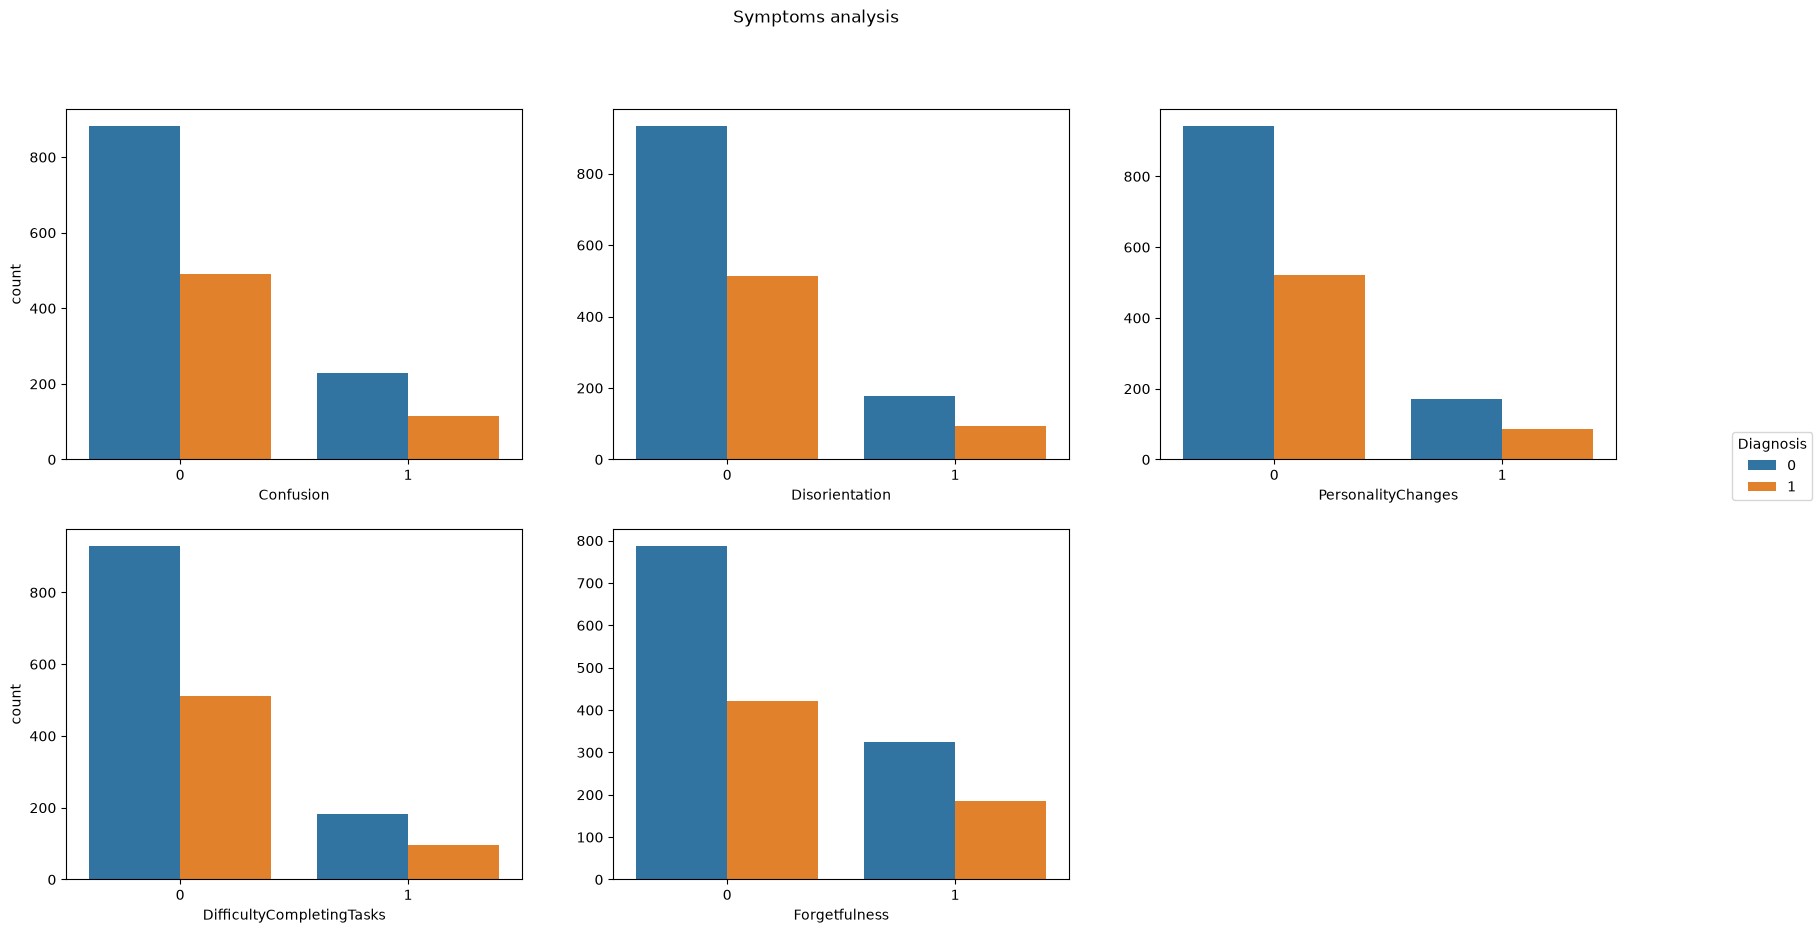

In [240]:
fig,ax = plt.subplots(2,3, figsize=(20,10))

sns.countplot(data=symp_df, x="Confusion", hue="Diagnosis", ax=ax[0,0],legend=False)
sns.countplot(data=symp_df, x="Disorientation", hue="Diagnosis", ax=ax[0,1],legend=True)
sns.countplot(data=symp_df, x="PersonalityChanges", hue="Diagnosis", ax=ax[0,2],legend=False)
sns.countplot(data=symp_df, x="DifficultyCompletingTasks", hue="Diagnosis", ax=ax[1,0],legend=False)
sns.countplot(data=symp_df, x="Forgetfulness", hue="Diagnosis", ax=ax[1,1],legend=False)

for i in range(2):
    for j in range(3):
        if [i,j] not in [[0,0], [1,0]]:
            ax[i,j].set_ylabel("")
        legend = ax[i,j].get_legend()
        if legend:
            legend.remove()
            

ax[-1,-1].remove()
fig.suptitle("Symptoms analysis")            
fig.legend(loc="center right", title="Diagnosis")
plt.show()


It's interesting that even though these may indicate the appearance of dementia, not necessarily one of these alone indicate that.

In [243]:
columns_to_combine = symp_cols[:-1]
symp_df['sympt'] = symp_df[columns_to_combine].apply(lambda row: ''.join(row.values.astype(str)), axis=1)
symp_df.head()

,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,sympt
0,0,0,0,0,0,0,00000
1,0,0,0,0,1,1,00001
2,0,0,1,1,0,1,00110
3,1,0,1,0,1,0,10101
4,0,1,0,0,0,1,01000


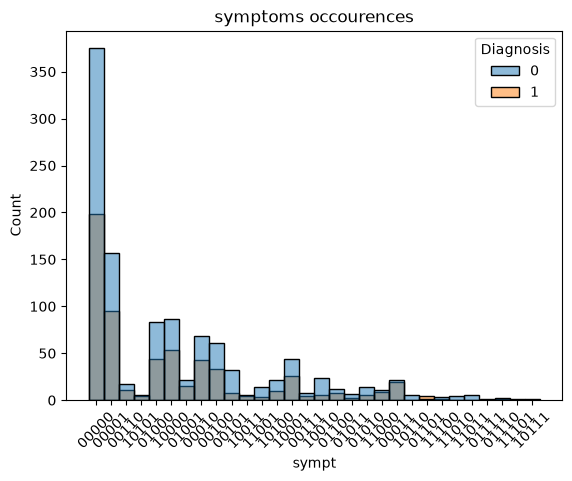

In [253]:
g = sns.histplot(data=symp_df,x="sympt",hue="Diagnosis")
g.tick_params(axis="x", rotation=45)
g.set_title("symptoms occourences")
plt.show()

I believe that the imbalancing is masking it, so cleaning is the next step

Maybe classifying numerical data and then cleaning similar rows